In [2]:
import pandas as pd
import yfinance as yf

In [3]:
def fetch_h4(symbol: str = "^DJI", period: str = "730d") -> pd.DataFrame:
    """
    XM's US30 CFD tracks the Dow Jones Industrial Average, so we use
    Yahoo Finance's "^DJI" as a free historical proxy. Yahoo only keeps
    60-minute data for ~730 days, so we pull hourly bars and resample
    them into 4-hour candles ourselves.
    """
    raw = yf.download(symbol, period=period, interval="60m", auto_adjust=True, progress=False)
    if raw.empty:
        raise RuntimeError(f"No data returned for {symbol}. Check the ticker or your network access.")

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    raw = raw.rename(columns=str.lower)
    raw = raw[["open", "high", "low", "close", "volume"]]

    h4 = raw.resample("4h").agg(
        {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"}
    ).dropna(how="any")

    h4.index.name = "time"
    return h4

In [4]:
df = fetch_h4()
print(df.shape)
print(df.head())
print(df.tail())

(1707, 5)
Price                              open          high           low  \
time                                                                  
2023-08-18 08:00:00-04:00  34368.359375  34548.308594  34263.191406   
2023-08-18 12:00:00-04:00  34501.578125  34587.070312  34424.921875   
2023-08-21 08:00:00-04:00  34531.281250  34570.960938  34248.460938   
2023-08-21 12:00:00-04:00  34362.648438  34538.261719  34342.710938   
2023-08-22 08:00:00-04:00  34494.171875  34514.039062  34283.851562   

Price                             close     volume  
time                                                
2023-08-18 08:00:00-04:00  34501.960938   69918626  
2023-08-18 12:00:00-04:00  34510.378906  124464537  
2023-08-21 08:00:00-04:00  34361.601562   71896678  
2023-08-21 12:00:00-04:00  34468.101562  160008903  
2023-08-22 08:00:00-04:00  34320.109375  117818527  
Price                              open          high           low  \
time                                              

In [5]:
import numpy as np

def sma(series, length):
    return series.rolling(window=length, min_periods=length).mean()

def ema(series, length):
    return series.ewm(span=length, adjust=False, min_periods=length).mean()

def macd(close, fast=12, slow=26, signal=9):
    macd_line = ema(close, fast) - ema(close, slow)
    signal_line = ema(macd_line, signal)
    hist = macd_line - signal_line
    return macd_line, signal_line, hist

def true_range(high, low, close):
    prev_close = close.shift(1)
    return pd.concat([high - low, (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)

def atr(high, low, close, length=14):
    tr = true_range(high, low, close)
    return tr.ewm(alpha=1/length, adjust=False, min_periods=length).mean()

def adx(high, low, close, length=14):
    up_move = high.diff()
    down_move = -low.diff()
    plus_dm = pd.Series(np.where((up_move > down_move) & (up_move > 0), up_move, 0.0), index=high.index)
    minus_dm = pd.Series(np.where((down_move > up_move) & (down_move > 0), down_move, 0.0), index=high.index)
    atr_wilder = true_range(high, low, close).ewm(alpha=1/length, adjust=False, min_periods=length).mean()
    plus_di = 100 * (plus_dm.ewm(alpha=1/length, adjust=False, min_periods=length).mean() / atr_wilder)
    minus_di = 100 * (minus_dm.ewm(alpha=1/length, adjust=False, min_periods=length).mean() / atr_wilder)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    adx_line = dx.ewm(alpha=1/length, adjust=False, min_periods=length).mean()
    return plus_di, minus_di, adx_line

In [6]:
df["ma_360"] = sma(df["close"], 360)
df["ma_200"] = sma(df["close"], 200)
df["ma_89"] = sma(df["close"], 89)
df["ema_21"] = ema(df["close"], 21)
df["ema_8"] = ema(df["close"], 8)

df["macd"], df["macd_signal"], df["macd_hist"] = macd(df["close"])
df["atr_14"] = atr(df["high"], df["low"], df["close"])
df["plus_di"], df["minus_di"], df["adx_14"] = adx(df["high"], df["low"], df["close"])

df.tail()

Price,open,high,low,close,volume,ma_360,ma_200,ma_89,ema_21,ema_8,macd,macd_signal,macd_hist,atr_14,plus_di,minus_di,adx_14
time,,,,,,,,,,,,,,,,,
2026-07-15 12:00:00-04:00,52471.031250,52695.460938,52436.359375,52658.019531,186584901,49244.396463,49449.851816,51292.188904,52454.739931,52530.763648,131.351741,179.471588,-48.119847,368.282603,18.547441,19.166102,16.857284
2026-07-16 08:00:00-04:00,52924.859375,52924.859375,52578.781250,52612.210938,101227504,49257.667969,49465.477617,51324.822639,52469.055477,52548.863046,128.699064,169.317083,-40.618019,366.696569,21.765552,17.874071,16.354417
2026-07-16 12:00:00-04:00,52611.480469,52728.878906,52367.421875,52553.078125,220100546,49271.147049,49480.712500,51358.679117,52476.693899,52549.799730,120.436953,159.541057,-39.104104,366.322316,20.231518,20.735569,15.274129
2026-07-17 08:00:00-04:00,52426.460938,52610.968750,51986.738281,52410.941406,104449161,49284.100141,49495.243652,51388.348358,52470.716400,52518.942325,101.252746,147.883395,-46.630649,384.744327,17.886894,25.400000,15.422873
2026-07-17 12:00:00-04:00,52410.730469,52419.000000,52120.718750,52158.960938,185019456,49295.995757,49508.549512,51416.836245,52442.374994,52438.946461,64.967501,131.300216,-66.332715,378.568393,16.880221,23.970489,15.560991


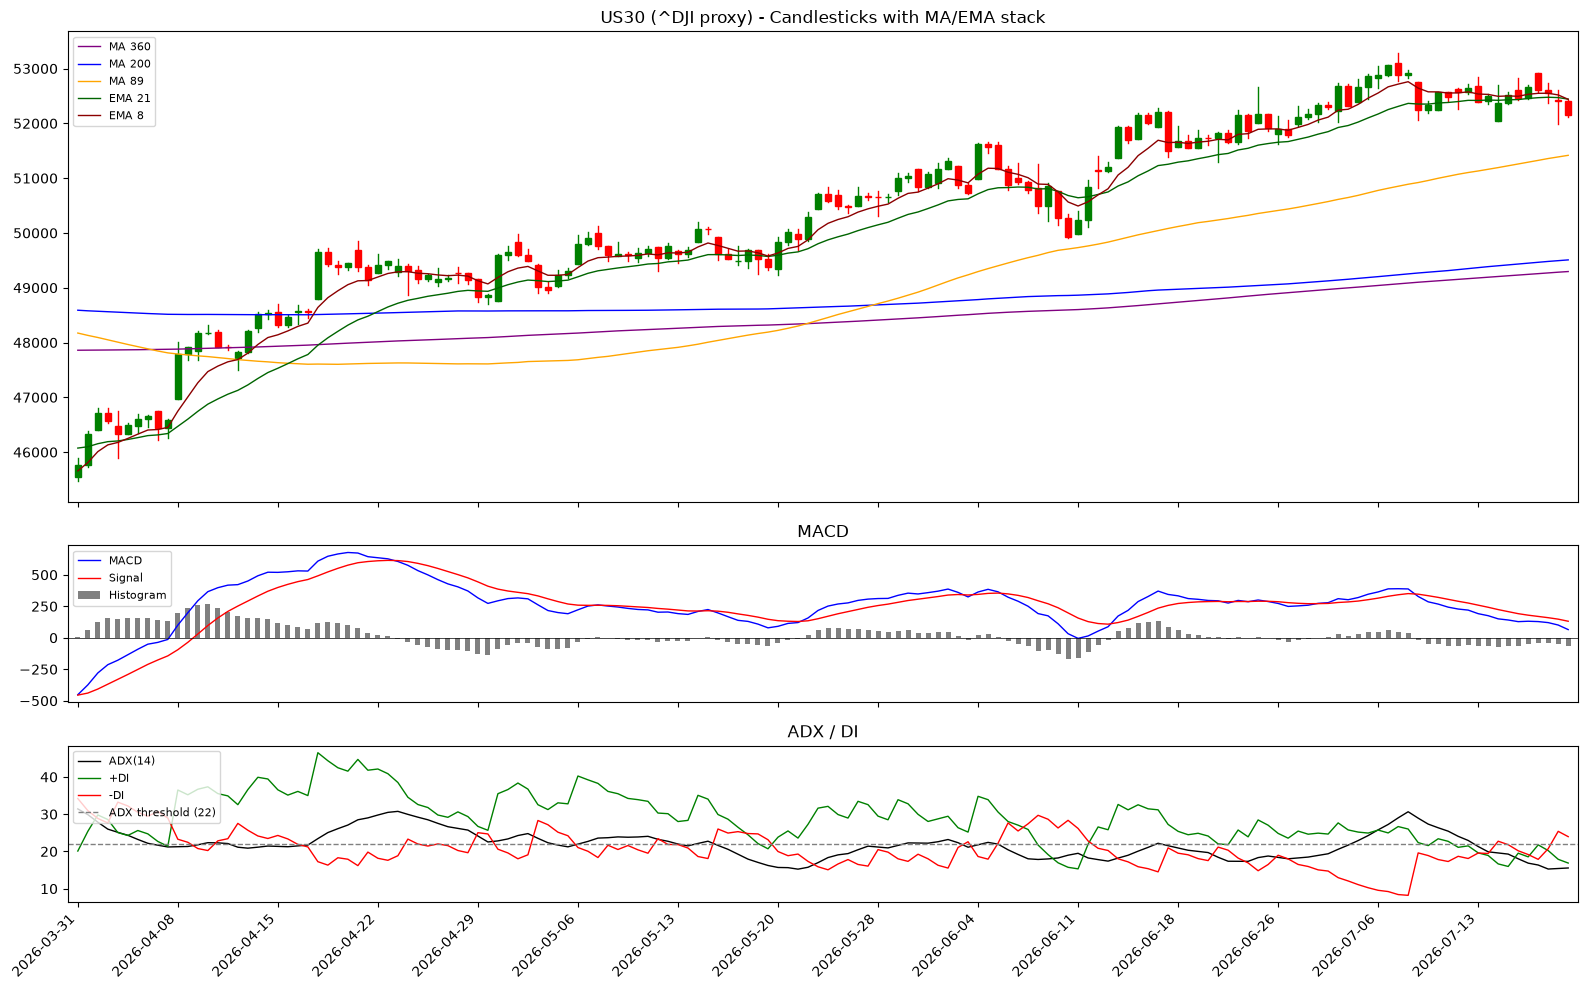

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

plot_df = df.tail(150)  # candlesticks need fewer bars than a line chart to stay readable

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1, 1]})

# Panel 1: candlesticks + MA/EMA stack
ax = axes[0]
for i, (idx, row) in enumerate(plot_df.iterrows()):
    color = "green" if row["close"] >= row["open"] else "red"
    ax.add_line(Line2D([i, i], [row["low"], row["high"]], color=color, linewidth=1))
    body_low = min(row["open"], row["close"])
    body_height = abs(row["close"] - row["open"]) or 0.01
    ax.add_patch(Rectangle((i - 0.3, body_low), 0.6, body_height, facecolor=color, edgecolor=color))

x = range(len(plot_df))
ax.plot(x, plot_df["ma_360"].values, label="MA 360", color="purple", linewidth=1)
ax.plot(x, plot_df["ma_200"].values, label="MA 200", color="blue", linewidth=1)
ax.plot(x, plot_df["ma_89"].values, label="MA 89", color="orange", linewidth=1)
ax.plot(x, plot_df["ema_21"].values, label="EMA 21", color="darkgreen", linewidth=1)
ax.plot(x, plot_df["ema_8"].values, label="EMA 8", color="darkred", linewidth=1)
ax.set_title("US30 (^DJI proxy) - Candlesticks with MA/EMA stack")
ax.legend(loc="upper left", fontsize=8)
ax.set_xlim(-1, len(plot_df))

# Panel 2: MACD
axes[1].plot(x, plot_df["macd"].values, label="MACD", color="blue", linewidth=1)
axes[1].plot(x, plot_df["macd_signal"].values, label="Signal", color="red", linewidth=1)
axes[1].bar(x, plot_df["macd_hist"].values, label="Histogram", color="gray", width=0.5)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].legend(loc="upper left", fontsize=8)
axes[1].set_title("MACD")

# Panel 3: ADX
axes[2].plot(x, plot_df["adx_14"].values, label="ADX(14)", color="black", linewidth=1)
axes[2].plot(x, plot_df["plus_di"].values, label="+DI", color="green", linewidth=1)
axes[2].plot(x, plot_df["minus_di"].values, label="-DI", color="red", linewidth=1)
axes[2].axhline(22, color="gray", linestyle="--", linewidth=1, label="ADX threshold (22)")
axes[2].legend(loc="upper left", fontsize=8)
axes[2].set_title("ADX / DI")

# x-axis: show a date every ~10 bars instead of every bar
tick_positions = list(range(0, len(plot_df), 10))
tick_labels = [plot_df.index[i].strftime("%Y-%m-%d") for i in tick_positions]
axes[2].set_xticks(tick_positions)
axes[2].set_xticklabels(tick_labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [9]:
bt_df = df.rename(columns={
    "open": "Open", "high": "High", "low": "Low", "close": "Close", "volume": "Volume"
})
bt_df.tail()

Price,Open,High,Low,Close,Volume,ma_360,ma_200,ma_89,ema_21,ema_8,macd,macd_signal,macd_hist,atr_14,plus_di,minus_di,adx_14
time,,,,,,,,,,,,,,,,,
2026-07-15 12:00:00-04:00,52471.031250,52695.460938,52436.359375,52658.019531,186584901,49244.396463,49449.851816,51292.188904,52454.739931,52530.763648,131.351741,179.471588,-48.119847,368.282603,18.547441,19.166102,16.857284
2026-07-16 08:00:00-04:00,52924.859375,52924.859375,52578.781250,52612.210938,101227504,49257.667969,49465.477617,51324.822639,52469.055477,52548.863046,128.699064,169.317083,-40.618019,366.696569,21.765552,17.874071,16.354417
2026-07-16 12:00:00-04:00,52611.480469,52728.878906,52367.421875,52553.078125,220100546,49271.147049,49480.712500,51358.679117,52476.693899,52549.799730,120.436953,159.541057,-39.104104,366.322316,20.231518,20.735569,15.274129
2026-07-17 08:00:00-04:00,52426.460938,52610.968750,51986.738281,52410.941406,104449161,49284.100141,49495.243652,51388.348358,52470.716400,52518.942325,101.252746,147.883395,-46.630649,384.744327,17.886894,25.400000,15.422873
2026-07-17 12:00:00-04:00,52410.730469,52419.000000,52120.718750,52158.960938,185019456,49295.995757,49508.549512,51416.836245,52442.374994,52438.946461,64.967501,131.300216,-66.332715,378.568393,16.880221,23.970489,15.560991


In [15]:
from backtesting import Strategy, Backtest

def swing_high(high, n):
    return high.rolling(n).max().shift(1)

def swing_low(low, n):
    return low.rolling(n).min().shift(1)

class ConfluenceStrategy(Strategy):
    adx_threshold = 22
    swing_lookback = 20
    atr_sl_mult = 1.5
    atr_tp_mult = 2.5

    def init(self):
        d = self.data.df
        self.ma_360 = self.I(lambda: d["ma_360"], name="MA360")
        self.ma_200 = self.I(lambda: d["ma_200"], name="MA200")
        self.ema_21 = self.I(lambda: d["ema_21"], name="EMA21")
        self.ema_8 = self.I(lambda: d["ema_8"], name="EMA8")
        self.macd_line = self.I(lambda: d["macd"], name="MACD")
        self.macd_signal = self.I(lambda: d["macd_signal"], name="MACDsig")
        self.macd_hist = self.I(lambda: d["macd_hist"], name="MACDhist")
        self.adx_14 = self.I(lambda: d["adx_14"], name="ADX14")
        self.atr_14 = self.I(lambda: d["atr_14"], name="ATR14")
        self.swing_hi = self.I(lambda: swing_high(d["High"], self.swing_lookback), name="SwingHi")
        self.swing_lo = self.I(lambda: swing_low(d["Low"], self.swing_lookback), name="SwingLo")

    def next(self):
        price = self.data.Close[-1]
        atr = self.atr_14[-1]

        if np.isnan(atr) or np.isnan(self.ma_360[-1]) or np.isnan(self.adx_14[-1]) or np.isnan(self.swing_hi[-1]):
            return

        trending = self.adx_14[-1] > self.adx_threshold
        ema_bullish = self.ema_8[-1] > self.ema_21[-1]
        ema_bearish = self.ema_8[-1] < self.ema_21[-1]
        macd_bull = self.macd_hist[-1] > 0
        macd_bear = self.macd_hist[-1] < 0
        bos_up = price > self.swing_hi[-1]
        bos_down = price < self.swing_lo[-1]
        macro_uptrend = price > self.ma_360[-1] and price > self.ma_200[-1]
        macro_downtrend = price < self.ma_360[-1] and price < self.ma_200[-1]

        long_signal = trending and macro_uptrend and ema_bullish and macd_bull and bos_up
        short_signal = trending and macro_downtrend and ema_bearish and macd_bear and bos_down

        if not self.position:
            if long_signal:
                sl = price - self.atr_sl_mult * atr
                tp = price + self.atr_tp_mult * atr
                if sl < price:
                    self.buy(sl=sl, tp=tp, size=0.1)
            elif short_signal:
                sl = price + self.atr_sl_mult * atr
                tp = price - self.atr_tp_mult * atr
                if sl > price:
                    self.sell(sl=sl, tp=tp, size=0.1)
        else:
            if self.position.is_long and price < self.ema_21[-1] and not macro_uptrend:
                self.position.close()
            elif self.position.is_short and price > self.ema_21[-1] and not macro_downtrend:
                self.position.close()

In [17]:
bt = Backtest(bt_df, ConfluenceStrategy, cash=50_000, commission=0.0002, margin=1/30)
stats = bt.run()
stats

C:\Users\milat\AppData\Local\Temp\ipykernel_15264\3466567226.py:1: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt = Backtest(bt_df, ConfluenceStrategy, cash=50_000, commission=0.0002, margin=1/30)


Start                     2023-08-18 08:00...
End                       2026-07-17 12:00...
Duration                   1064 days 04:00:00
Exposure Time [%]                    16.11013
Equity Final [$]                  45591.88646
Equity Peak [$]                   59826.79243
Commissions [$]                    2046.79976
Return [%]                           -8.81623
Buy & Hold Return [%]                34.56539
Return (Ann.) [%]                    -3.13579
Volatility (Ann.) [%]                12.49055
CAGR [%]                             -2.16184
Sharpe Ratio                         -0.25105
Sortino Ratio                        -0.34003
Calmar Ratio                         -0.13179
Alpha [%]                             -9.7257
Beta                                  0.02631
Max. Drawdown [%]                   -23.79353
Avg. Drawdown [%]                     -3.9884
Max. Drawdown Duration      466 days 04:00:00
Avg. Drawdown Duration       66 days 10:00:00
# Trades                          

In [18]:
stats_opt, heatmap = bt.optimize(
    adx_threshold=range(15, 31, 5),
    swing_lookback=range(10, 41, 10),
    atr_sl_mult=[1.0, 1.5, 2.0, 2.5],
    atr_tp_mult=[1.5, 2.0, 2.5, 3.0, 3.5, 4.0],
    maximize="SQN",
    constraint=lambda p: p.atr_tp_mult > p.atr_sl_mult,
    return_heatmap=True,
)
stats_opt

c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of 

Start                     2023-08-18 08:00...
End                       2026-07-17 12:00...
Duration                   1064 days 04:00:00
Exposure Time [%]                    35.79379
Equity Final [$]                  94201.55041
Equity Peak [$]                   98707.25353
Commissions [$]                    2339.62307
Return [%]                            88.4031
Buy & Hold Return [%]                34.56539
Return (Ann.) [%]                    24.44054
Volatility (Ann.) [%]                29.33426
CAGR [%]                              16.1829
Sharpe Ratio                          0.83317
Sortino Ratio                         1.60036
Calmar Ratio                          1.39654
Alpha [%]                            85.25752
Beta                                    0.091
Max. Drawdown [%]                   -17.50074
Avg. Drawdown [%]                    -2.87455
Max. Drawdown Duration      423 days 00:00:00
Avg. Drawdown Duration       21 days 05:00:00
# Trades                          

In [19]:
print(stats_opt._strategy)

ConfluenceStrategy(adx_threshold=15,swing_lookback=20,atr_sl_mult=2.0,atr_tp_mult=4.0)


In [20]:
split_date = "2025-08-18"  # roughly last ~11 months held out as unseen test data

train_df = bt_df.loc[:split_date]
test_df = bt_df.loc[split_date:]

print(f"Train: {train_df.index[0]} to {train_df.index[-1]}  ({len(train_df)} bars)")
print(f"Test:  {test_df.index[0]} to {test_df.index[-1]}  ({len(test_df)} bars)")

bt_train = Backtest(train_df, ConfluenceStrategy, cash=50_000, commission=0.0002, margin=1/30)
stats_train_opt, _ = bt_train.optimize(
    adx_threshold=range(15, 31, 5),
    swing_lookback=range(10, 41, 10),
    atr_sl_mult=[1.0, 1.5, 2.0, 2.5],
    atr_tp_mult=[1.5, 2.0, 2.5, 3.0, 3.5, 4.0],
    maximize="SQN",
    constraint=lambda p: p.atr_tp_mult > p.atr_sl_mult,
    return_heatmap=True,
)
print(stats_train_opt._strategy)
stats_train_opt

Train: 2023-08-18 08:00:00-04:00 to 2025-08-18 12:00:00-04:00  (1166 bars)
Test:  2025-08-18 08:00:00-04:00 to 2026-07-17 12:00:00-04:00  (543 bars)


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  for stats in (bt.run(**params)
c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of 

ConfluenceStrategy(adx_threshold=15,swing_lookback=20,atr_sl_mult=1.0,atr_tp_mult=2.5)


c:\Users\milat\Documents\us30-trading-bot\venv\Lib\site-packages\backtesting\backtesting.py:1545: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats = self.run(**dict(zip(heatmap.index.names, best_params)))


Start                     2023-08-18 08:00...
End                       2025-08-18 12:00...
Duration                    731 days 04:00:00
Exposure Time [%]                    18.26758
Equity Final [$]                  81913.72924
Equity Peak [$]                   82979.29012
Commissions [$]                    2100.69805
Return [%]                           63.82746
Buy & Hold Return [%]                 15.8636
Return (Ann.) [%]                    28.18441
Volatility (Ann.) [%]                18.39201
CAGR [%]                             18.54667
Sharpe Ratio                          1.53243
Sortino Ratio                         3.67336
Calmar Ratio                          3.27499
Alpha [%]                            63.67351
Beta                                   0.0097
Max. Drawdown [%]                    -8.60595
Avg. Drawdown [%]                    -1.90659
Max. Drawdown Duration       87 days 00:00:00
Avg. Drawdown Duration       18 days 11:00:00
# Trades                          

In [21]:
bt_test = Backtest(test_df, ConfluenceStrategy, cash=50_000, commission=0.0002, margin=1/30)
stats_test = bt_test.run(
    adx_threshold=15,
    swing_lookback=20,
    atr_sl_mult=1.0,
    atr_tp_mult=2.5,
)
stats_test

C:\Users\milat\AppData\Local\Temp\ipykernel_15264\3957173952.py:1: UserWarning: Some prices are larger than initial cash value. Note that fractional trading is not supported by this class. If you want to trade Bitcoin, increase initial cash, or trade μBTC or satoshis instead (see e.g. class `backtesting.lib.FractionalBacktest`.
  bt_test = Backtest(test_df, ConfluenceStrategy, cash=50_000, commission=0.0002, margin=1/30)


Start                     2025-08-18 08:00...
End                       2026-07-17 12:00...
Duration                    333 days 04:00:00
Exposure Time [%]                    23.75691
Equity Final [$]                   42342.1978
Equity Peak [$]                   50085.41535
Commissions [$]                     796.03228
Return [%]                           -15.3156
Buy & Hold Return [%]                15.85731
Return (Ann.) [%]                   -16.65153
Volatility (Ann.) [%]                 10.7058
CAGR [%]                            -11.81554
Sharpe Ratio                         -1.55537
Sortino Ratio                        -1.65793
Calmar Ratio                         -1.07707
Alpha [%]                           -20.23462
Beta                                   0.3102
Max. Drawdown [%]                   -15.46002
Avg. Drawdown [%]                    -9.97199
Max. Drawdown Duration      261 days 04:00:00
Avg. Drawdown Duration      143 days 14:00:00
# Trades                          